In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Memory Data Analysis

##  Card Frequency Data Analysis 

In [4]:
mem_df = pd.read_csv("./Data/with_memory_sim_card_frequency.txt")#, index_col=0)
mem_df.head().style.set_properties(**{'text-align': 'center'})

,run,card_id,card_frequency
0,0,4,6
1,0,48,4
2,0,3,2
3,0,41,5
4,0,43,1


### Card Frequency Max Value By Run

In [6]:
mem_df_max_frequency  = mem_df.groupby('run')['card_frequency'].max().reset_index()
mem_df_max_frequency.head().style.set_properties(**{'text-align': 'center'})

,run,card_frequency
0,0,7
1,1,5
2,2,5
3,3,6
4,4,5


In [7]:
std = mem_df_max_frequency['card_frequency'].std()
print("STD Max Card Frequency:",round(std,3))

STD Max Card Frequency: 0.852


In [8]:
mean = mem_df_max_frequency['card_frequency'].mean()
print("Mean Max Card Frequency:",mean)

Mean Max Card Frequency: 5.61


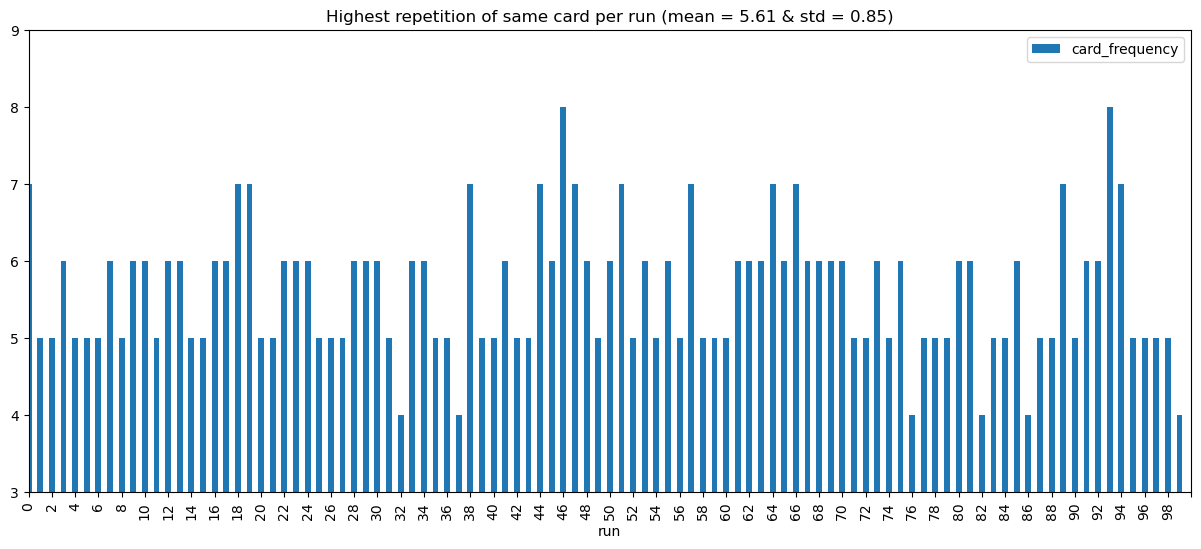

In [9]:
ax = mem_df_max_frequency.plot(
    kind = 'bar', 
    x ='run', 
    y ='card_frequency', 
    figsize = (15, 6), 
    title = (f"Highest repetition of same card per run (mean = {mean:.2f} & std = {std:.2f})")
)
plt.xlim(0,100)
plt.ylim(3,9)

plt.xticks(np.arange(0, 101, step = 2)) # Marcas no X de 10 em 10
plt.yticks(np.arange(3, 10, step = 1))

plt.show()

### Frequency of Max Values

In [17]:
mem_df_max_counts = mem_df_max_frequency['card_frequency'].value_counts().reset_index()
mem_df_max_counts.columns = ['max_repetition', 'frequency'] #rename
mem_df_max_counts = mem_df_max_counts.sort_values(by='max_repetition')
mem_df_max_counts.head()

,max_repetition,frequency
3,4,6
0,5,43
1,6,37
2,7,12
4,8,2


### Mean Frequencies by Run 

1 - groupby('run'): Ele junta todos os dados do Run 1, depois todos do Run 2, etc.
['card_frequency'].

2 - mean(): Ele soma todas as frequências das cartas que apareceram no Run 1 e divide pelo número de cartas diferentes que saíram nesse run.

3 - Resultado: Vais ter 100 linhas (uma por run). Se o Run 1 der 2.5, significa que, em média, as cartas que saíram nesse run apareceram 2.5 vezes cada uma.

In [20]:
mem_df_mean  = mem_df.groupby('run')['card_frequency'].mean().reset_index()
print(mem_df_mean.round(2).head())

   run  card_frequency
0    0            2.33
1    1            2.17
2    2            2.13
3    3            2.17
4    4            2.22


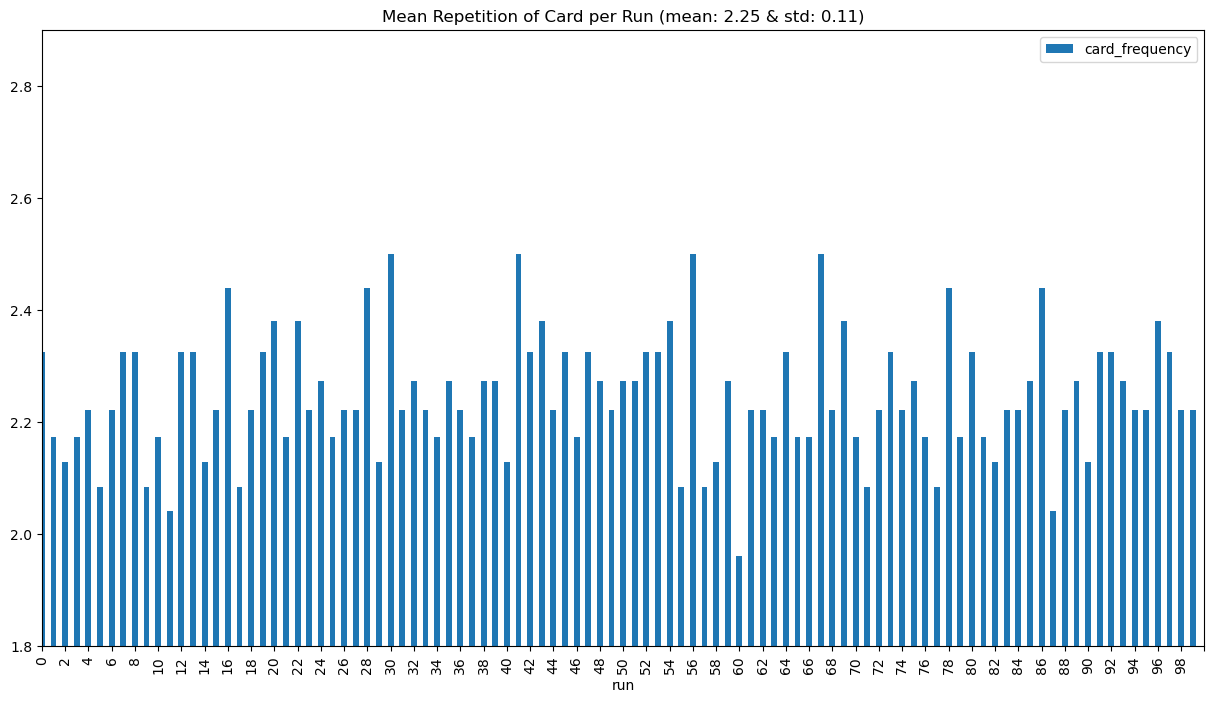

In [32]:
ax = mem_df_mean.plot(
    kind='bar', 
    x='run', 
    y='card_frequency', 
    figsize=(15, 8), 
    title=f"Mean Repetition of Card per Run (mean: {round(mem_df_mean['card_frequency'].mean(),2)} & std: {round(mem_df_mean['card_frequency'].std(),2)})"   
)

plt.xlim(0,99)
plt.ylim(1.8,2.9)

plt.xticks(np.arange(0, 101, step = 2))
plt.yticks(np.arange(1.8, 2.9, step = 0.2))

plt.show()

### Frequency of Cards

In [25]:
mem_df_mean_counts = mem_df_mean['card_frequency'].value_counts().reset_index()
mem_df_mean_counts.columns = ['mean_repetition', 'frequency'] #rename

print(mem_df_mean_counts.round(2).head())

   mean_repetition  frequency
0             2.22         24
1             2.33         17
2             2.17         15
3             2.27         13
4             2.13          7


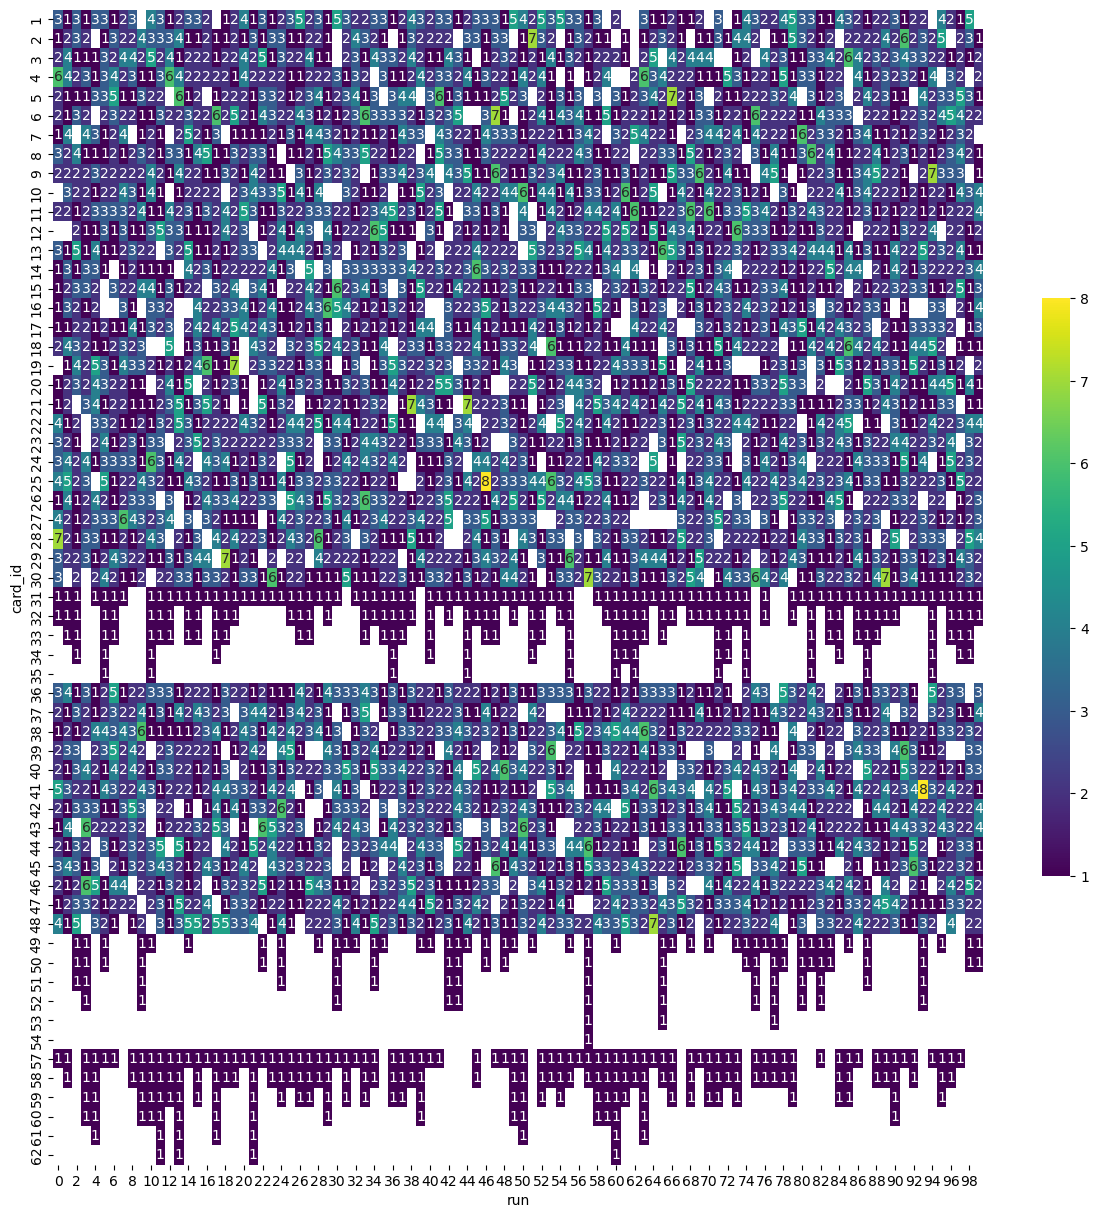

In [27]:
plt.figure(figsize=(15,15))

result = mem_df.pivot(index='card_id', columns='run', values='card_frequency')
sns.heatmap(result, annot=True, fmt="g", cmap='viridis',cbar_kws={"shrink": 0.5},)

plt.show()

### Amount of Times a Card is Displayed in 100 Runs

In [30]:
mem_df_total_card_count =  mem_df.groupby('card_id')['card_frequency'].sum().reset_index()
mem_df_total_card_count.columns = ['card_id', 'card_count'] #rename

mem_df_total_card_count.head()
mem_df_total_card_count.tail()

,card_id,card_count
55,58,62
56,59,38
57,60,17
58,61,8
59,62,4


In [32]:
std = mem_df_total_card_count['card_count'].std()
mean = mem_df_total_card_count['card_count'].mean()

print("STD  Card Count:",round(std,3))
print("Mean Card Count:",round(mean,3))

STD  Card Count: 87.239
Mean Card Count: 166.667


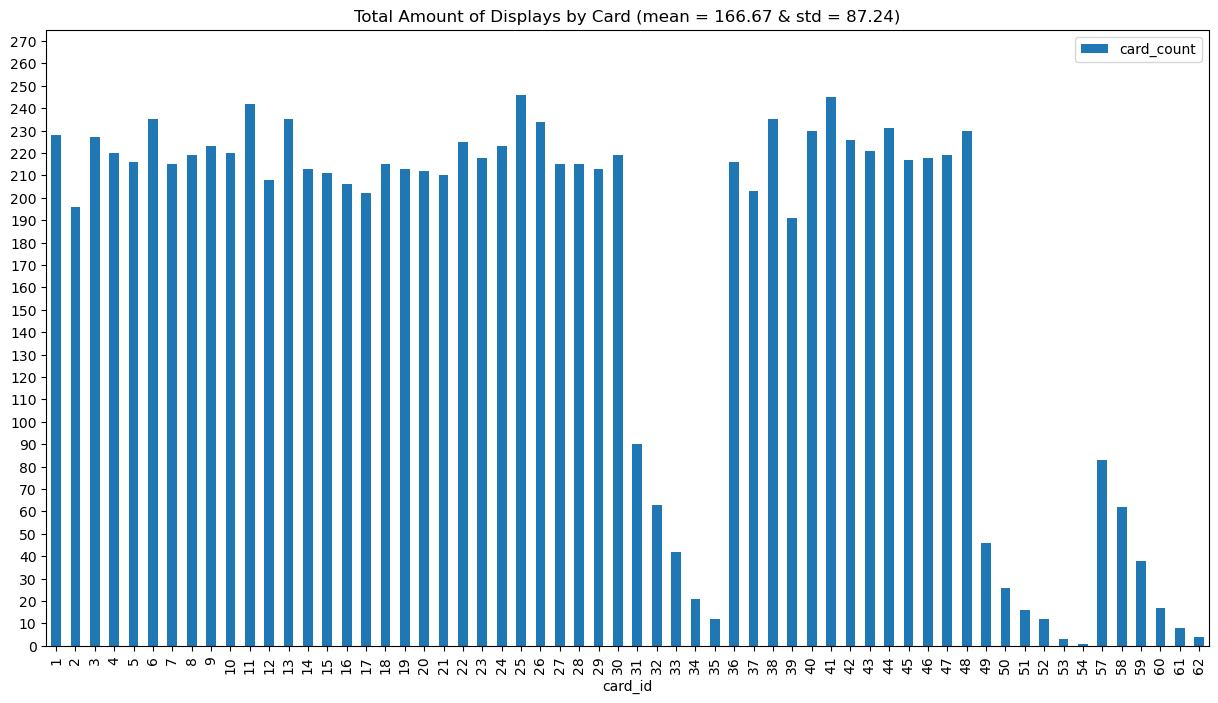

In [34]:
ax = mem_df_total_card_count.plot(
    kind='bar', 
    x='card_id', 
    y='card_count', 
    figsize=(15, 8), 
    title=(f"Total Amount of Displays by Card (mean = {mean:.2f} & std = {std:.2f})")
)

plt.ylim(190,275)
#plt.xlim(0,48)

#plt.xticks(np.arange(0, 48, step = 1))
plt.yticks(np.arange(0, 275, step = 10))

plt.show()

### Average Card Display Times

In [37]:
mem_df_total_card_count =  mem_df.groupby('card_id')['card_frequency'].sum().reset_index()
mem_df_total_card_count.columns = ['card_id', 'card_count'] #rename
mem_df_average_card_count = mem_df_total_card_count
mem_df_average_card_count["card_count_real_mean"] = mem_df_total_card_count["card_count"]/100 #média real != mean(média das runs em que aparece)

print(mem_df_average_card_count.head())


   card_id  card_count  card_count_real_mean
0        1         228                  2.28
1        2         196                  1.96
2        3         227                  2.27
3        4         220                  2.20
4        5         216                  2.16


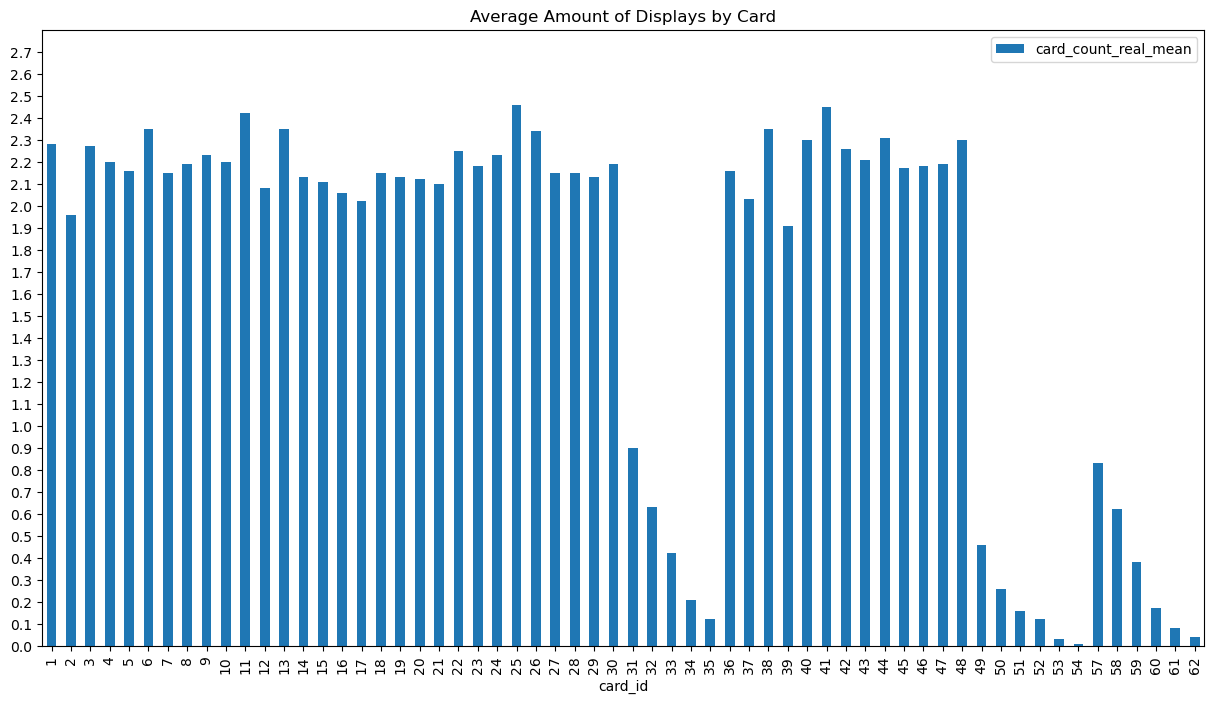

In [39]:
ax = mem_df_average_card_count.plot(
    kind='bar', 
    x ='card_id', 
    y ='card_count_real_mean', 
    figsize = (15, 8), 
    title = "Average Amount of Displays by Card"   
)
plt.ylim(0,2.8)
plt.yticks(np.arange(0, 2.8, step = 0.1))

plt.show()

### Mean Card Display Times and Presence %


In [58]:
# 1. MÉDIA GLOBAL (Média de 'presença' em 100 runs)
# Se der 1.0, significa que em média vês 1 carta destas por run (total de 100 em 100 runs)
mem_mean_global = mem_df.groupby('card_id')['card_frequency'].sum() / 100

# 2. MÉDIA DE INTENSIDADE (Média de 'amontoado' quando aparece)
# Se a carta aparece 100 vezes num só run e 0 nos outros 99, este valor será 100!
mem_mean_intensity = mem_df.groupby('card_id')['card_frequency'].mean()

# 3 Em quantos runs (dos 100) a carta apareceu?
mem_presence_count = mem_df.groupby('card_id')['run'].nunique()
mem_presence_percentage = (mem_presence_count / 100) * 100

# Criar o DF para comparar
mem_df_compare = pd.DataFrame({
    'Presence (%)': mem_presence_percentage,
    'Global (Espalhado)': mem_mean_global,
    'Intensidade (Concentrado)': mem_mean_intensity
    
})
print(mem_df_compare.round(2).head())


         Presence (%)  Global (Espalhado)  Intensidade (Concentrado)
card_id                                                             
1                91.0                2.28                       2.51
2                88.0                1.96                       2.23
3                93.0                2.27                       2.44
4                92.0                2.20                       2.39
5                89.0                2.16                       2.43


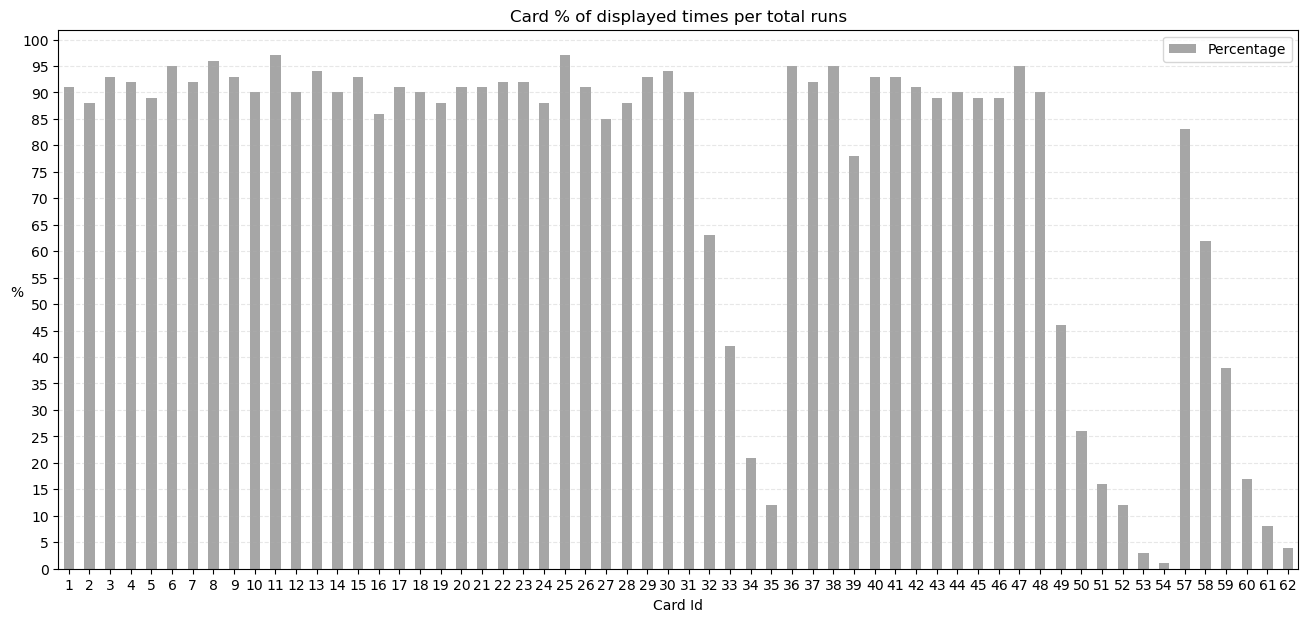

In [184]:
mem_mean_intensity = mem_mean_intensity.reindex(mem_mean_global.index)

plt.figure(figsize=(16, 7))

# 2. Desenha as barras e guarda o objeto 'ax'
ax = mem_presence_percentage.plot(kind = 'bar', color='black', alpha=.35, label='Percentage')

plt.title("Card % of displayed times per total runs")
#plt.ylim(0,3)
plt.yticks(np.arange(0, 101, step = 5))

plt.xticks(range(len(mem_mean_global)), mem_mean_global.index, rotation=0)
plt.xlabel("Card Id")
plt.ylabel("%", rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


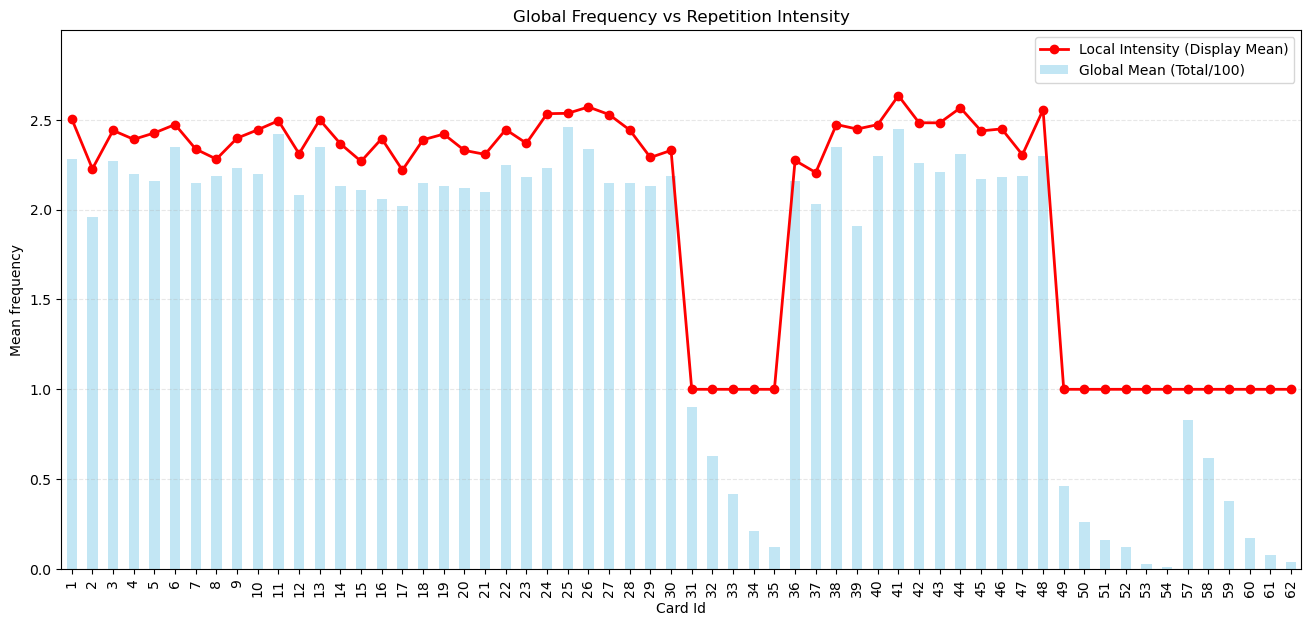

In [44]:
# 1. Garante que ambos têm exatamente os mesmos IDs (o reindex resolve o "salto")
mem_mean_intensity = mem_mean_intensity.reindex(mem_mean_global.index)

plt.figure(figsize=(16, 7))

# 2. Desenha as barras e guarda o objeto 'ax'
ax = mem_mean_global.plot(kind='bar', color='skyblue', alpha=0.5, label='Global Mean (Total/100)')

# 3. TRUQUE: Usa os números das posições (0, 1, 2...) para a linha bater certo com as barras
plt.plot(range(len(mem_mean_intensity)), mem_mean_intensity.values, marker='o', color='red', label='Local Intensity (Display Mean)', linewidth=2)

plt.title("Global Frequency vs Repetition Intensity")
plt.ylim(0,3)
plt.yticks(np.arange(0, 3, step = 0.5))

plt.xticks(range(len(mem_mean_global)), mem_mean_global.index, rotation=90)
plt.xlabel("Card Id")
plt.ylabel("Mean frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


## Run Summary Data Analysis

In [46]:
mem_df1_original = pd.read_csv("./Data/with_memory_sim_summary.txt")

### Mean Values & Standart Deviation

In [13]:
mem_df1 = pd.read_csv("./Data/with_memory_sim_summary.txt")
mem_df1 = mem_df1.rename(columns={'final_wealth': 'final_resources','final_morale': 'final_security', 'final_stability': 'final_moral'})

mem_df1.head()

,run,unique_cards,repetitions,final_resources,final_security,final_moral,final_progress
0,0,43,57,-200,235,25,500
1,1,46,54,-200,370,0,345
2,2,47,53,-55,305,30,460
3,3,46,54,30,255,-10,325
4,4,45,55,-40,245,-25,340


In [17]:
mem_df1_mean_wv = mem_df1.drop(['run', 'repetitions'], axis = 1).mean()
mem_df1_mean_wv['Std'] = mem_df1['unique_cards'].std()
mem_df1_mean_wv = mem_df1_mean_wv.loc[['unique_cards','Std','final_resources', 'final_security','final_moral','final_progress']] 

In [19]:
print(mem_df1_mean_wv.round(2))

unique_cards        44.63
Std                  2.15
final_resources   -125.40
final_security     308.50
final_moral          0.10
final_progress     372.00
dtype: float64


### Absolute Card  Variance

In [22]:
unique_card_mean = mem_df1['unique_cards'].mean()
mem_df1['Mean Dev'] = mem_df1['unique_cards'] - unique_card_mean

col_deviation = mem_df1.pop('Mean Dev')
mem_df1.insert(2, 'Mean Dev', col_deviation)
mem_df1 = mem_df1.drop(['run', 'repetitions'], axis = 1)

In [24]:
mem_df1.head().style.set_properties(**{'text-align': 'center'}).format(precision=2)

,unique_cards,Mean Dev,final_resources,final_security,final_moral,final_progress
0,43,-1.63,-200,235,25,500
1,46,1.37,-200,370,0,345
2,47,2.37,-55,305,30,460
3,46,1.37,30,255,-10,325
4,45,0.37,-40,245,-25,340


### Absolute World Values Variance

In [27]:
resources_mean = mem_df1['final_resources'].mean()
moral_mean = mem_df1['final_moral'].mean()
security_mean = mem_df1['final_security'].mean()
progress_mean = mem_df1['final_progress'].mean()

# Usamos .abs() se quiseres apenas a distância, ou deixamos sem se quiseres valores positivos/negativos
mem_df1['rsc_dv'] = mem_df1['final_resources'] - resources_mean
mem_df1['moral_dv'] = mem_df1['final_moral'] - moral_mean
mem_df1['sec_dv'] = mem_df1['final_security'] - security_mean
mem_df1['prog_dv'] = mem_df1['final_progress'] - progress_mean

In [29]:
mem_df1 = mem_df1[['unique_cards','Mean Dev','final_resources','rsc_dv','final_security', 'sec_dv','final_moral','moral_dv','final_progress','prog_dv']]

In [35]:
print(f"Means: Resources: {resources_mean:.2f} | Security: {security_mean:.2f}| Moral: {moral_mean:.2f}| Progress: {progress_mean:.2f}") 

Means: Resources: -125.40 | Security: 308.50| Moral: 0.10| Progress: 372.00


In [37]:
mem_df1.head().style.set_properties(**{'text-align': 'center'}).format(precision=2)

,unique_cards,Mean Dev,final_resources,rsc_dv,final_security,sec_dv,final_moral,moral_dv,final_progress,prog_dv
0,43,-1.63,-200,-74.60,235,-73.50,25,24.90,500,128.00
1,46,1.37,-200,-74.60,370,61.50,0,-0.10,345,-27.00
2,47,2.37,-55,70.40,305,-3.50,30,29.90,460,88.00
3,46,1.37,30,155.40,255,-53.50,-10,-10.10,325,-47.00
4,45,0.37,-40,85.40,245,-63.50,-25,-25.10,340,-32.00


### World Variables Standart Deviation Graph


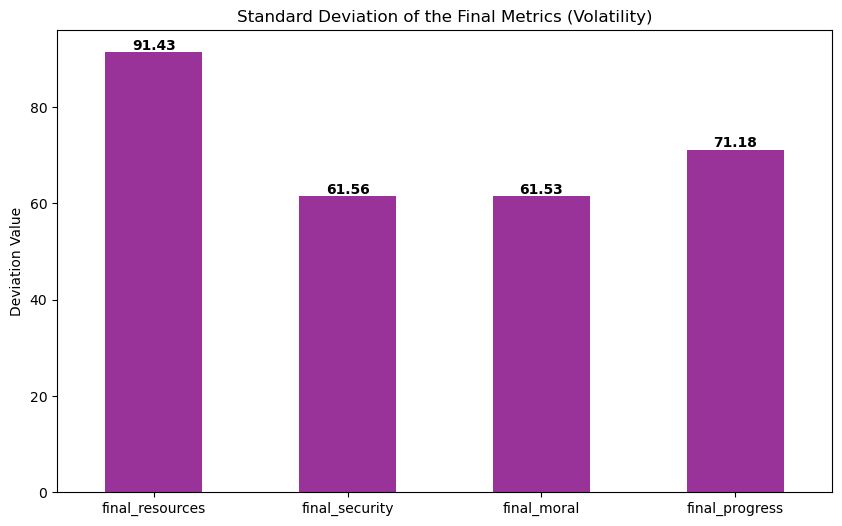

In [40]:
# Selecionar as colunas de métricas do Ficheiro 3 (Sumário)
metricas = ['final_resources', 'final_security', 'final_moral', 'final_progress']
std_values = mem_df1[metricas].std()

# Plot
std_values.plot(kind='bar', figsize=(10, 6), color='purple', alpha=0.8)
plt.title("Standard Deviation of the Final Metrics (Volatility)")
plt.ylabel("Deviation Value")
plt.xticks(rotation=0)

# Adicionar os valores por cima das barras para leitura fácil
for i, v in enumerate(std_values):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


### Graphs Card Variation to mean

In [73]:
std = mem_df1_original['unique_cards'].std()
print("STD card variation to mean:",round(std,2))

STD card variation to mean: 2.15


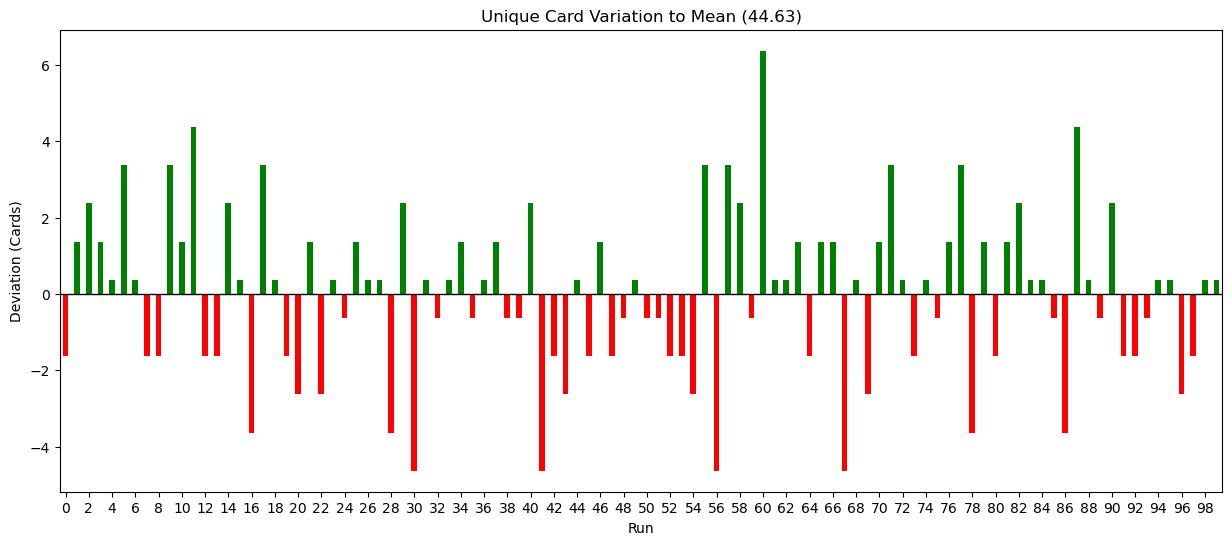

In [74]:
# 1. Calcular o desvio (como fizemos antes)
media = mem_df1['unique_cards'].mean()
mem_df1['Desvio'] = mem_df1['unique_cards'] - media
# 2. Definir as cores com base no valor (Positivo = Verde, Negativo = Vermelho)
cores = ['green' if x > 0 else 'red' for x in mem_df1['Desvio']]

# 3. Criar o gráfico
plt.figure(figsize=(15, 6))
mem_df1['Desvio'].plot(kind='bar', color=cores)

plt.xticks(np.arange(0, 100, step = 2))
plt.xticks(rotation = 0)

plt.axhline(0, color='black', linewidth=1) # Linha do zero (a média)
plt.title(f"Unique Card Variation to Mean ({media:.2f})")
plt.xlabel("Run")
plt.ylabel("Deviation (Cards)")
plt.show()

## Logs Analysis

### Card Exhaustion Graph

In [77]:
mem_df_logs = pd.read_csv("./Data/with_memory_sim_log.txt", index_col=0)

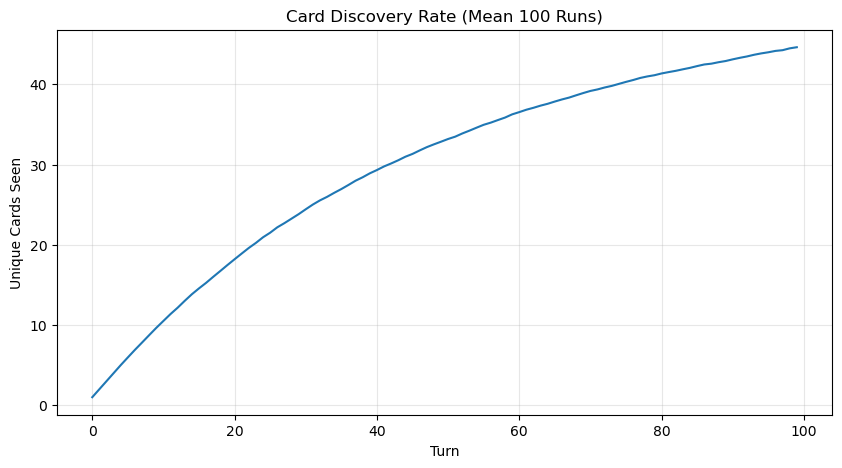

In [79]:
mem_df_newcard_rate = mem_df_logs
# 1. Criar uma coluna que marca se a carta é nova naquele run
mem_df_newcard_rate['is_new'] = mem_df_newcard_rate.groupby('run')['card_id'].transform(lambda x: ~x.duplicated())

# 2. Somar cumulativamente as cartas novas por run
mem_df_newcard_rate['cards_discovered'] = mem_df_newcard_rate.groupby('run')['is_new'].cumsum()

# 3. Tirar a média de descoberta de todos os runs por turno
mem_df_newcard_rate = mem_df_newcard_rate.groupby('turn')['cards_discovered'].mean()

# Plot
mem_df_newcard_rate.plot(figsize=(10, 5), title="Card Discovery Rate (Mean 100 Runs)")
plt.xlabel("Turn")
plt.ylabel("Unique Cards Seen")
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
mem_df_logs = pd.read_csv("./Data/with_memory_sim_log.txt", index_col=0)
df_logs = pd.read_csv("./Data/no_memory_sim_log.txt", index_col=0)
mem_no_arcs_df_logs = pd.read_csv("./Data/with_memory_sim_log.txt")#, index_col=0)

In [7]:
arc_ids = [31,32,33,34,35,49,50,51,52,53,54,55,56,57,58,59,60,61,62]
# Remove esses IDs
mem_no_arcs_df_logs = mem_no_arcs_df_logs[~mem_no_arcs_df_logs['card_id'].isin(arc_ids)].reset_index(drop=True)

,run,turn,card_id,choice,wealth,morale,stability,progress
0,0,0,4,0,35,65,50,50
1,0,1,48,1,35,65,50,50
2,0,2,3,0,50,65,45,50
3,0,3,41,0,40,80,45,50
4,0,4,43,0,60,80,35,50


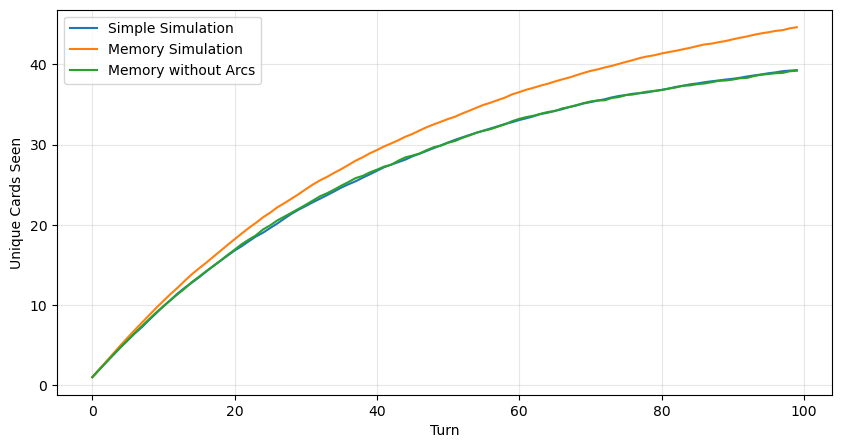

In [23]:
def get_discovery_rate(df):
    temp_df = df.copy()
    temp_df['is_new'] = temp_df.groupby('run')['card_id'].transform(lambda x: ~x.duplicated())
    temp_df['cards_discovered'] = temp_df.groupby('run')['is_new'].cumsum()
    return temp_df.groupby('turn')['cards_discovered'].mean()

datasets = {
    "Simple Simulation": df_logs,
    "Memory Simulation": mem_df_logs,
    "Memory without Arcs": mem_no_arcs_df_logs
}

plt.figure(figsize=(10, 5))
ax = None

for label, data in datasets.items():
    discovery_rate = get_discovery_rate(data)
    # No primeiro item criamos o 'ax', nos seguintes reaproveitamos
    ax = discovery_rate.plot(ax=ax, label=label)


# Plot
#ax = df_newcard_rate_simple.plot(figsize=(10, 5), title ="Card Discovery Rate (Mean 100 Runs)",label = 'Simple Simulation')
#mem_df_newcard_rate_memory.plot(ax=ax,label='Memory Simulation')
#df_newcard_rate_no_arcs.plot(ax=ax,label='Memory without Arcs')

plt.legend()
plt.xlabel("Turn")
plt.ylabel("Unique Cards Seen")
plt.grid(True, alpha=0.3)
plt.show()


### Recurrence Index (Distância entre a mesma carta)
Este código calcula quantos turnos passaram desde a última vez que a mesma carta apareceu.
Num sistema com memória, este número deve ser sempre alto. No simples, verás muitos "1" ou "2" (cartas a repetir quase logo a seguir).

Distância média entre a mesma carta: 25.95 turnos
Mínima distância registada: 5.0 turnos


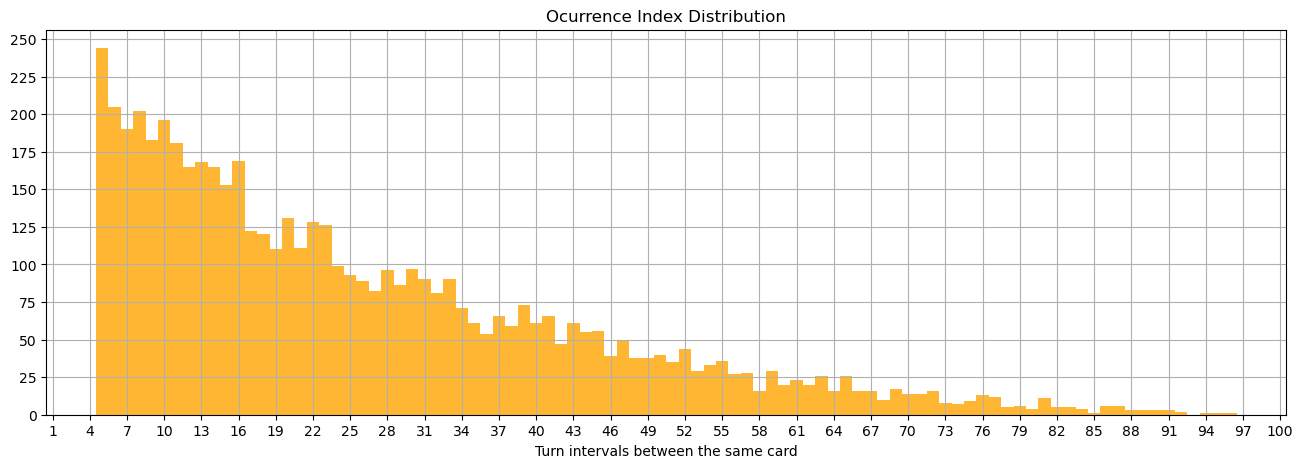

In [141]:
mem_df_recurrence = mem_df_logs

# Calcular a distância (diff) entre turnos para o mesmo card_id dentro de cada run
mem_df_recurrence = mem_df_recurrence.sort_values(['run', 'turn'])
mem_df_recurrence['distancia_recorrencia'] = mem_df_recurrence.groupby(['run', 'card_id'])['turn'].diff()

# Filtrar NaN (primeira aparição não tem distância)
mem_df_recurrence = mem_df_recurrence['distancia_recorrencia'].dropna()

print(f"Distância média entre a mesma carta: {mem_df_recurrence.mean():.2f} turnos")
print(f"Mínima distância registada: {mem_df_recurrence.min()} turnos")

# Ver a distribuição (Histograma)
#mem_df_recurrence.hist(bins = 100, figsize=(12, 5), color='orange', alpha=0.7,grid=True)

plt.figure(figsize=(16, 5))
bins_inteiros = np.arange(0.5, 101.5, 1)
mem_df_recurrence.hist(bins = bins_inteiros, color = 'orange' , alpha=0.8, edgecolor='none')

# Força os ticks do X a baterem certo com as barras
plt.xlim(0.5, 100.5)

plt.title("Ocurrence Index Distribution")#Distribuição do Índice de Recorrência")
plt.xlabel("Turn intervals between the same card")# Turnos de intervalo entre a mesma carta")
plt.xticks(np.arange(1, 101, step = 3))
plt.yticks(np.arange(0, 275, step = 25))

plt.show()


Distância média entre a mesma carta: 23.02 turnos
Mínima distância registada: 1.0 turnos
Distância média entre a mesma carta: 25.95 turnos
Mínima distância registada: 5.0 turnos


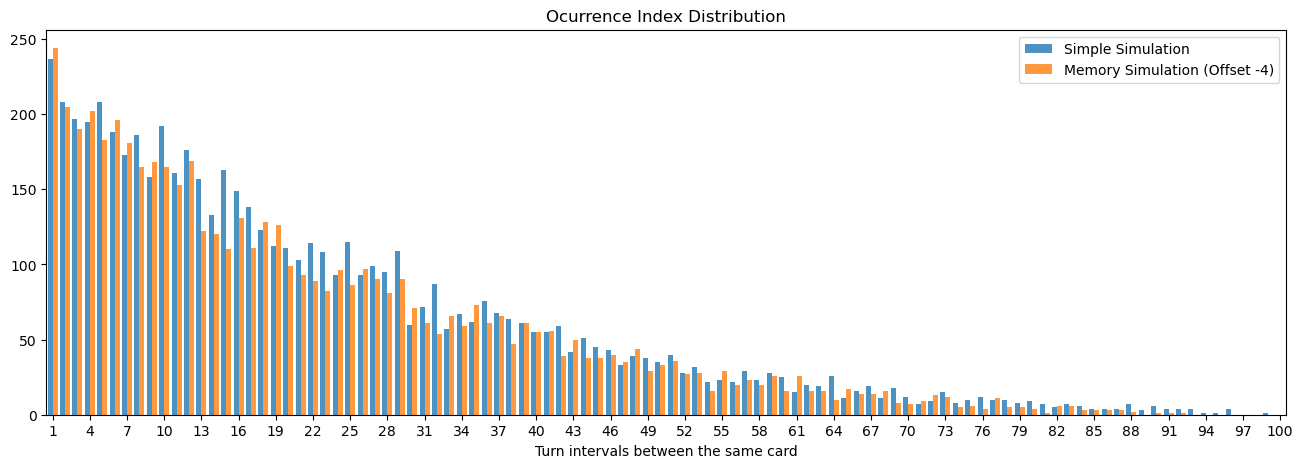

In [129]:
def recurrence(df):
    df = df.copy()
    df = df.sort_values(['run', 'turn'])
    df['distancia_recorrencia'] = df.groupby(['run', 'card_id'])['turn'].diff()
    df = df['distancia_recorrencia'].dropna()
    print(f"Distância média entre a mesma carta: {df.mean():.2f} turnos")
    print(f"Mínima distância registada: {df.min()} turnos")
    return df
    

datasets = {
    "Simple Simulation (mean: 23.02)": df_logs,
    "Memory Simulation (mean: 25.95)": mem_df_logs,
}

plt.figure(figsize=(16, 5))

# 1. Criar listas para guardar os dados e os nomes
all_data = []
all_labels = []

for label, df in datasets.items():
    ocurrence_index = recurrence(df)
    
    # Se quiseres manter o alinhamento artificial (subtrair 4)
    if label == "Memory Simulation":
        ocurrence_index = ocurrence_index - 4
        label = f"{label} (Offset -4)" # Renomeia para ficar claro no gráfico

        
    all_data.append(ocurrence_index)
    all_labels.append(label)




# Cria limites que caem exatamente entre os números inteiros
# [0.5, 1.5, 2.5 ... 100.5]
bins_inteiros = np.arange(0.5, 101.5, 1)
plt.hist(all_data, bins=bins_inteiros, label=all_labels, alpha=0.8, edgecolor='none')

plt.legend()
plt.title("Ocurrence Index Distribution")#Distribuição do Índice de Recorrência")
plt.xlabel("Turn intervals between the same card")# Turnos de intervalo entre a mesma carta")



# Força os ticks do X a baterem certo com as barras
plt.xticks(np.arange(1, 101, 3)) 
plt.xlim(0.5, 100.5)
plt.show()

### World Values Evolution

In [46]:
df_logs = pd.read_csv("./Data/with_memory_sim_log.txt")
df_logs = df_logs.rename(columns={'wealth': 'resources','morale': 'security', 'stability': 'moral'})

In [48]:
df_memory_wv_rate_example = df_logs

df_memory_wv_rate_example = df_memory_wv_rate_example.loc[df_memory_wv_rate_example['run'] == 43]
df_memory_wv_rate_example.head()

,run,turn,card_id,choice,resources,security,moral,progress
4300,43,0,31,1,50,50,60,50
4301,43,1,39,0,40,65,60,50
4302,43,2,26,1,50,65,55,50
4303,43,3,49,0,50,60,55,65
4304,43,4,38,0,40,70,55,65


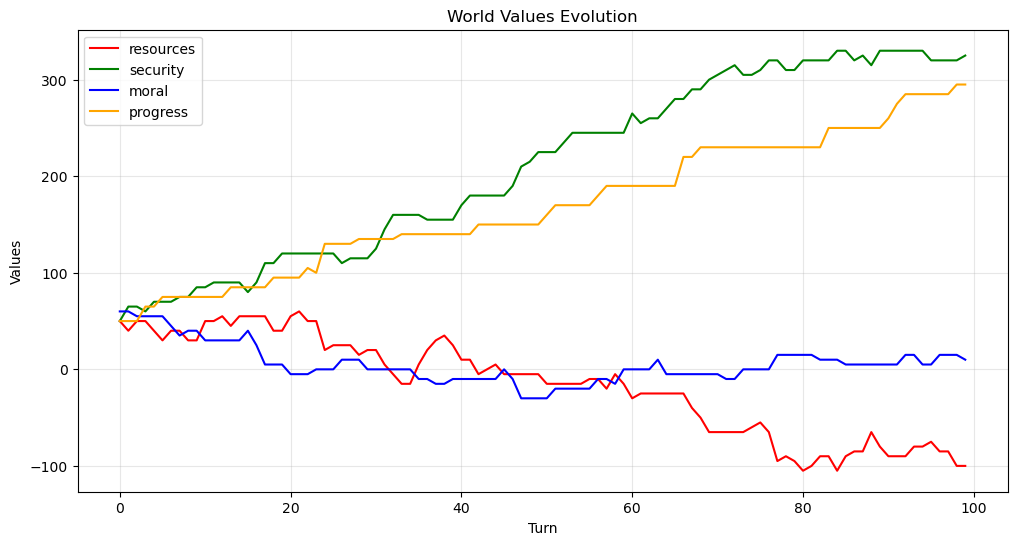

In [50]:
'''O .loc[...] funciona como um "localizador". 
Ele pega na lista de True e False que vimos acima
e diz ao Pandas: "Mostra-me apenas as linhas onde o resultado
foi True, mantendo todas as colunas intactas".'''

df_memory_wv_rate_example.plot(
    x="turn", 
    y=["resources","security","moral","progress"], 
    color=['r', 'g', 'b', 'orange'], 
    figsize=(12, 6),
    title="World Values Evolution"
)


# Plot
#df_memory_wv_rate_example.plot(figsize=(10, 5), title="World Values Evolution")
plt.title("World Values Evolution")
plt.xlabel("Turn")
plt.ylabel("Values")
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
df_memory_wv_rate = df_logs
# 1. Criar uma coluna que marca se a carta é nova naquele run
df_memory_wv_rate = df_memory_wv_rate.groupby('turn')[['resources','security','moral','progress']].mean().reset_index()
df_memory_wv_rate.head()

,turn,resources,security,moral,progress
0,0,47.90,51.70,51.05,53.10
1,1,45.65,53.90,50.60,57.50
2,2,44.35,55.75,50.90,61.45
3,3,43.35,57.40,49.95,64.70
4,4,41.75,60.60,49.05,67.45


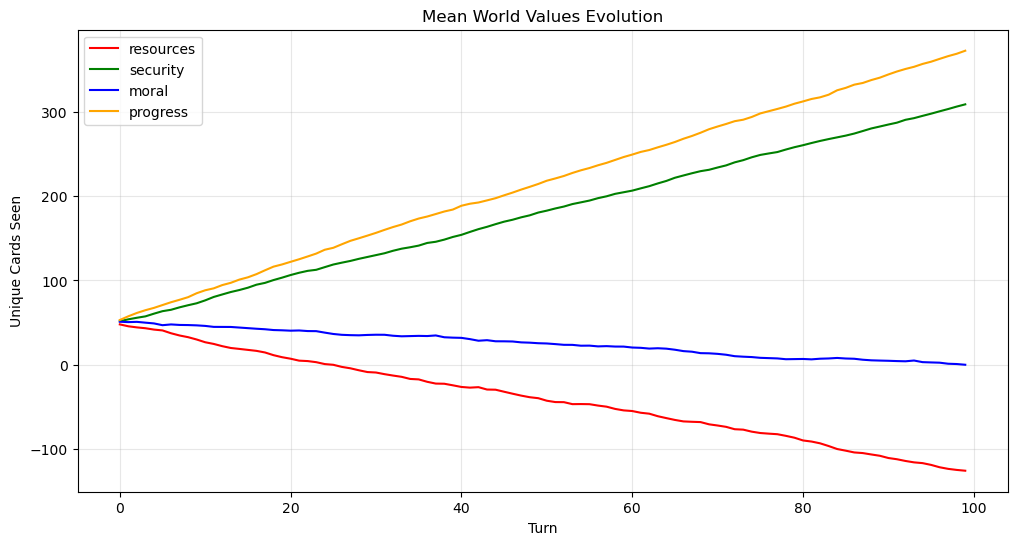

In [76]:
df_memory_wv_rate.plot(
    x="turn", 
    y=["resources","security","moral","progress"], 
    color=['r', 'g', 'b', 'orange'], 
    figsize=(12, 6),
    title="Mean World Values Evolution"
)
# Plot
plt.xlabel("Turn")
plt.ylabel("Unique Cards Seen")
plt.grid(True, alpha=0.3)
plt.show()

### Overlapped Comparison 

#### Example Turn

In [56]:
df_logs_no_memory = pd.read_csv("./Data/no_memory_sim_log.txt")
df_logs_no_memory = df_logs_no_memory.rename(columns={'wealth': 'resources','morale': 'security', 'stability': 'moral'})
df_wv_rate_example = df_logs_no_memory

df_wv_rate_example = df_wv_rate_example.loc[df_wv_rate_example['run'] == 43]


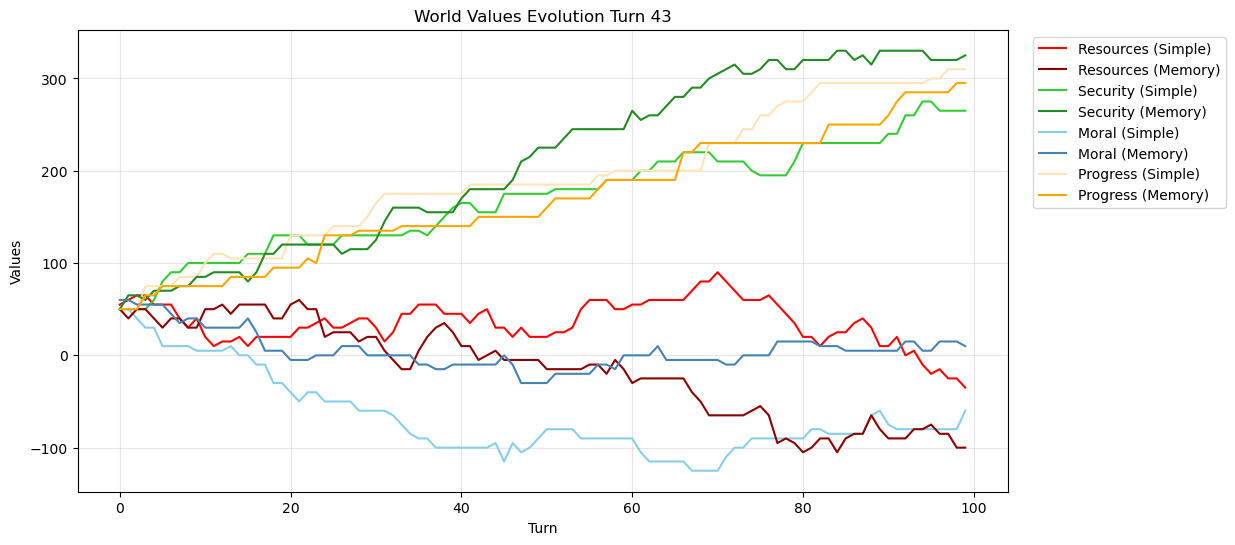

In [84]:
ax = df_wv_rate_example.plot(
    x="turn", 
    y=["resources","security","moral","progress"], 
    color=['r', 'limegreen', 'skyblue', 'moccasin'], 
    figsize=(12, 6),
)
df_memory_wv_rate_example.plot(
    x="turn", 
    y=["resources","security","moral","progress"], 
    color=['darkred', 'forestgreen', 'steelblue', 'orange'], 
    figsize=(12, 6),
    ax = ax
)

# 3. TRUQUE: Capturar as linhas criadas e reorganizá-las
handles, labels = ax.get_legend_handles_labels()

# Atualmente a ordem é: [Simples_Res, Simples_Sec, Simples_Mor, Simples_Prog, Mem_Res, Mem_Sec, Mem_Mor, Mem_Prog]
# Vamos criar uma nova ordem que intercala por tema (Simples vs Memória)
ordem_intercalada_handles = [
    handles[0], handles[4],  # Resources
    handles[1], handles[5],  # Security
    handles[2], handles[6],  # Moral
    handles[3], handles[7]   # Progress
]

nomes_intercalados = [
    "Resources (Simple)", "Resources (Memory)",
    "Security (Simple)",  "Security (Memory)",
    "Moral (Simple)",     "Moral (Memory)",
    "Progress (Simple)",  "Progress (Memory)"
]

# 4. Aplicar a nova ordem e nomes na legenda
plt.legend(ordem_intercalada_handles, nomes_intercalados, loc="upper left", bbox_to_anchor=(1.02, 1))

# Plot
plt.title("World Values Evolution Turn 43")
plt.xlabel("Turn")
plt.ylabel("Values")
plt.grid(True, alpha=0.3)
plt.show()

#### Mean

In [99]:
df_wv_rate = df_logs_no_memory
df_wv_rate = df_wv_rate.groupby('turn')[['resources','security','moral','progress']].mean().reset_index()
df_wv_rate.head()

,turn,resources,security,moral,progress
0,0,48.20,53.30,49.30,52.70
1,1,46.90,55.90,48.70,56.45
2,2,44.65,57.10,48.35,60.00
3,3,44.00,59.10,47.50,62.95
4,4,42.65,61.65,46.75,65.50


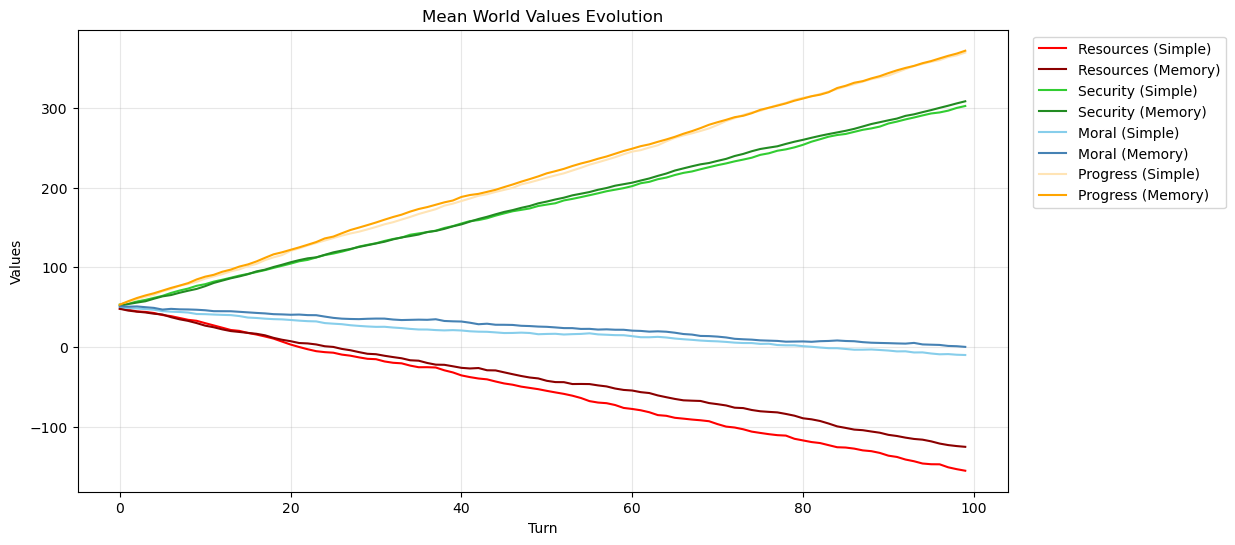

In [101]:
ax = df_wv_rate.plot(
    x="turn", 
    y=["resources","security","moral","progress"], 
    color=['r', 'limegreen', 'skyblue', 'moccasin'], 
    figsize=(12, 6),
)
df_memory_wv_rate.plot(
    x="turn", 
    y=["resources","security","moral","progress"], 
    color=['darkred', 'forestgreen', 'steelblue', 'orange'], 
    figsize=(12, 6),
    ax = ax
)

# 3. TRUQUE: Capturar as linhas criadas e reorganizá-las
handles, labels = ax.get_legend_handles_labels()

# Atualmente a ordem é: [Simples_Res, Simples_Sec, Simples_Mor, Simples_Prog, Mem_Res, Mem_Sec, Mem_Mor, Mem_Prog]
# Vamos criar uma nova ordem que intercala por tema (Simples vs Memória)
ordem_intercalada_handles = [
    handles[0], handles[4],  # Resources
    handles[1], handles[5],  # Security
    handles[2], handles[6],  # Moral
    handles[3], handles[7]   # Progress
]

nomes_intercalados = [
    "Resources (Simple)", "Resources (Memory)",
    "Security (Simple)",  "Security (Memory)",
    "Moral (Simple)",     "Moral (Memory)",
    "Progress (Simple)",  "Progress (Memory)"
]

# 4. Aplicar a nova ordem e nomes na legenda
plt.legend(ordem_intercalada_handles, nomes_intercalados, loc="upper left", bbox_to_anchor=(1.02, 1))

# Plot
plt.title("Mean World Values Evolution")
plt.xlabel("Turn")
plt.ylabel("Values")
plt.grid(True, alpha=0.3)
plt.show()